# 05 · Auditoría por grupos

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


In [2]:
estimator=pipeline();estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
from bank_ops.monitor import fairness
probability=estimator.predict_proba(test[FEATURES])[:,1]
groups=pd.DataFrame(fairness(test,probability));display(groups)

,group,n,positives,negatives,selection_rate,tpr,fpr,reliable
0,18-29,1713,578,1135,0.060712,0.084775,0.048458,True
1,30-59,6236,1802,4434,0.057409,0.080466,0.048038,True
2,60-100,1094,476,618,0.156307,0.147059,0.163430,True


## Denominadores antes que brechas
Los grupos son pedagógicos. El indicador de volumen no sustituye intervalos de confianza.

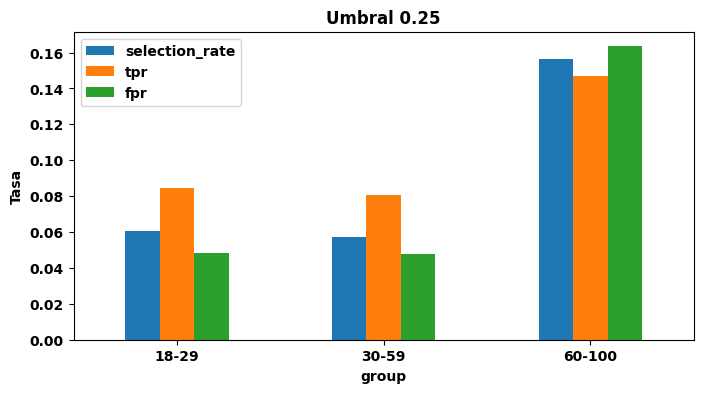

,group,n,positives,negatives,selection_rate,tpr,fpr,reliable
0,18-29,2,0.0,2.0,0.5,NaN,0.5,False
1,30-59,0,NaN,NaN,NaN,NaN,NaN,False
2,60-100,0,NaN,NaN,NaN,NaN,NaN,False


In [3]:
import matplotlib.pyplot as plt
groups.set_index("group")[["selection_rate","tpr","fpr"]].plot.bar(figsize=(8,4),rot=0)
plt.ylabel("Tasa");plt.title("Umbral 0.25");plt.show()
display(pd.DataFrame(fairness(pd.DataFrame({"age":[20,21],"y":["no","no"]}),[.1,.3])))

## Discusión
Distinguir diferencias observadas de discriminación causal. Identificar daño de falsos positivos y negativos. Test final se usa para informe, no para ajustar decisiones.